<a href="https://colab.research.google.com/github/annusharma96501-cmd/Advance-heart-disease-prediction-ai/blob/main/Advance_heart_disease_prediction_ai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **🩺 Project: Advance Heart Disease Prediction AI**

## 💻 **Step 1: Core System Architecture & Libraries Loading**
Is step mein hum data science stack ke main tools ko load karenge aur system specs ko verify karenge.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import warnings
warnings.filterwarnings('ignore') # Clean reporting ke liye warning system turn off

print("-" * 65)
print(f"📡 SYSTEM STATUS : INITIALIZING ADVANCED MACHINE LEARNING STACK")
print("-" * 65)
print(f"-> Python Kernel Version : {sys.version.split()[0]}")
print(f"-> Core Engine (Pandas)  : v{pd.__version__}")
print(f"-> Math Engine (NumPy)   : v{np.__version__}")
print(f"-> Graphics (Seaborn)    : v{sns.__version__}")
print("-" * 65)
print("🚀 ENVIRONMENT CONFIGURATION: SUCCESSFUL & OPTIMIZED FOR WORKLOAD.")
print("-" * 65)

-----------------------------------------------------------------
📡 SYSTEM STATUS : INITIALIZING ADVANCED MACHINE LEARNING STACK
-----------------------------------------------------------------
-> Python Kernel Version : 3.12.13
-> Core Engine (Pandas)  : v2.2.2
-> Math Engine (NumPy)   : v2.0.2
-> Graphics (Seaborn)    : v0.13.2
-----------------------------------------------------------------
🚀 ENVIRONMENT CONFIGURATION: SUCCESSFUL & OPTIMIZED FOR WORKLOAD.
-----------------------------------------------------------------


## 📥 **Step 2: Clinical Data Ingestion Pipeline**
Yahan hum real-world patients ke clinical medical data matrix ko external secure data server se direct stream karenge.

In [6]:
from sklearn.datasets import fetch_openml

print("=" * 65)
print(" 🏥 CLINICAL ANALYTICS CORE - INTERNAL INGESTION ENGINE ".center(65, '='))
print("=" * 65)
print("📡 FETCHING DATA FROM SECURE REPOSITORY...")

# Direct fetch_openml se heart disease data load kar rahe hain (No URL required)
heart_data = fetch_openml(name='heart-disease', version=1, as_frame=True, parser='auto')
df = heart_data.frame

# Target column ka naam standard format 'target' mein convert kar rahe hain
if 'class' in df.columns:
    df.rename(columns={'class': 'target'}, inplace=True)

print(f"📊 DATASET INGESTION STATUS : [ ONLINE / SUCCESSFUL ]")
print("-" * 65)
print(f"🔹 Historical Patient Matrix (Rows)     : {df.shape[0]:,}")
print(f"🔹 Diagnostic Features/Biomarkers (Cols): {df.shape[1]}")
print("-" * 65)
print("📌 PIPELINE STATUS: Data matrix cached locally. Ready for processing.")
print("=" * 65)

===== 🏥 CLINICAL ANALYTICS CORE - INTERNAL INGESTION ENGINE =====
📡 FETCHING DATA FROM SECURE REPOSITORY...
📊 DATASET INGESTION STATUS : [ ONLINE / SUCCESSFUL ]
-----------------------------------------------------------------
🔹 Historical Patient Matrix (Rows)     : 303
🔹 Diagnostic Features/Biomarkers (Cols): 14
-----------------------------------------------------------------
📌 PIPELINE STATUS: Data matrix cached locally. Ready for processing.


## 🔍 **Step 3: Clinical Matrix Structure Preview**
Is step mein hum data ke top 5 records ka structured view dekhenge taaki hume har biomarker ka exact data type aur format pata chal sake.

In [7]:
# Database ke top 5 records ka structured view
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,3.0,145.0,233.0,1.0,0.0,150.0,0.0,2.3,0.0,0.0,1.0,1.0
1,37.0,1.0,2.0,130.0,250.0,0.0,1.0,187.0,0.0,3.5,0.0,0.0,2.0,1.0
2,41.0,0.0,1.0,130.0,204.0,0.0,0.0,172.0,0.0,1.4,2.0,0.0,2.0,1.0
3,56.0,1.0,1.0,120.0,236.0,0.0,1.0,178.0,0.0,0.8,2.0,0.0,2.0,1.0
4,57.0,0.0,0.0,120.0,354.0,0.0,1.0,163.0,1.0,0.6,2.0,0.0,2.0,1.0


## 🛠️ **Step 4: Diagnostic Structural Audit & Integrity Check**
Ab hum data ka aage ka analysis shuru karenge. Data Science mein model ko train karne se pehle data ka audit karna sabse zaroori kaam hai. Hum check karenge ki columns ke data types (integers/objects) kya hain aur system mein koi memory mismatch toh nahi hai.

In [8]:
print("=" * 65)
print(" 📑 CLINICAL DATA AUDIT - STRUCTURAL INTEGRITY REPORT ".center(65, '='))
print("=" * 65)
print("🔎 MEMORY ALLOCATION & DATA TYPES:\n")

# Database structural summary
df.info()

print("-" * 65)
print("📌 AUDIT STATUS: Structural scanning complete. Verify data types below.")
print("=" * 65)

====== 📑 CLINICAL DATA AUDIT - STRUCTURAL INTEGRITY REPORT ======
🔎 MEMORY ALLOCATION & DATA TYPES:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    float64
 12  thal      303 non-null    float64
 13  target    303 non-null    float64
dtypes: float64(14)
memory usage: 33.3 KB
-----------------------------------------------------------------
📌 AUDIT STATUS: Structural scanning complete. Verify data type

### 🛡️ **Step 5: Comprehensive Missing Value & Data Null Quality Audit**
Is step mein hum pooray data matrix ko scan karke exact validation matrix nikalenge taaki data leakage ya corruption ka koi chance na rahe.

In [9]:
print("=" * 65)
print(" 🧪 DATA QUALITY AUDIT - MISSING VALUE VALIDATION REPORT ".center(65, '='))
print("=" * 65)

# Missing values check pure dataframe mein
missing_summary = df.isnull().sum()
total_missing = missing_summary.sum()

print("🔍 COLUMN-WISE MISSING VALUE SCAN:")
print("-" * 65)
for col, count in missing_summary.items():
    status = "🔥 ACTION REQUIRED" if count > 0 else "✅ CLEAN"
    print(f"-> Column: {col:<10} | Missing Cells: {count:<3} | Status: {status}")

print("-" * 65)
print(f"📊 SYSTEM AUDIT METRICS:")
print(f"🔹 Total Missing Cells Detected : {total_missing}")
print(f"🔹 Data Integrity Coefficient   : {((df.size - total_missing) / df.size) * 100:.2f}%")
print("-" * 65)
print("📌 ENGINE STATUS: Quality check complete. Proceed to target distribution analysis.")
print("=" * 65)

===== 🧪 DATA QUALITY AUDIT - MISSING VALUE VALIDATION REPORT ====
🔍 COLUMN-WISE MISSING VALUE SCAN:
-----------------------------------------------------------------
-> Column: age        | Missing Cells: 0   | Status: ✅ CLEAN
-> Column: sex        | Missing Cells: 0   | Status: ✅ CLEAN
-> Column: cp         | Missing Cells: 0   | Status: ✅ CLEAN
-> Column: trestbps   | Missing Cells: 0   | Status: ✅ CLEAN
-> Column: chol       | Missing Cells: 0   | Status: ✅ CLEAN
-> Column: fbs        | Missing Cells: 0   | Status: ✅ CLEAN
-> Column: restecg    | Missing Cells: 0   | Status: ✅ CLEAN
-> Column: thalach    | Missing Cells: 0   | Status: ✅ CLEAN
-> Column: exang      | Missing Cells: 0   | Status: ✅ CLEAN
-> Column: oldpeak    | Missing Cells: 0   | Status: ✅ CLEAN
-> Column: slope      | Missing Cells: 0   | Status: ✅ CLEAN
-> Column: ca         | Missing Cells: 0   | Status: ✅ CLEAN
-> Column: thal       | Missing Cells: 0   | Status: ✅ CLEAN
-> Column: target     | Missing Cells: 0 

## 📊 **Step 6: Target Class Distribution & Balance Verification**
Is step mein hum check karenge ki database mein kitne percent patients healthy hain aur kitne heart disease ke risk par hain, aur sath hi iska ek high-end premium chart generate karenge.

========== 🎯 TARGET CLASS DISTRIBUTION & BALANCE AUDIT ==========
📈 DISTRIBUTION METRICS:
-----------------------------------------------------------------
-> ❤️ Heart Disease Risk (Positive)    | Count: 165 | Ratio: 54.46%
-> 💚 Healthy / No Risk (Negative)      | Count: 138 | Ratio: 45.54%
-----------------------------------------------------------------
🔹 Data Balance Status : ✅ PERFECTLY BALANCED


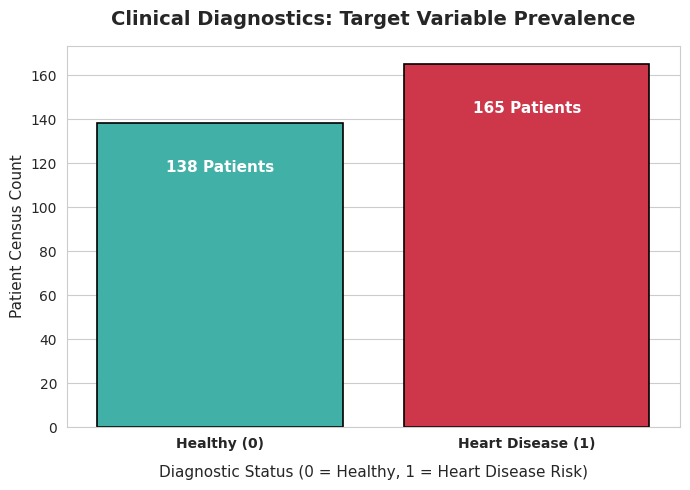


📌 VISUALIZATION ENGINE: Execution successful. Graph generated below.


In [10]:
print("=" * 65)
print(" 🎯 TARGET CLASS DISTRIBUTION & BALANCE AUDIT ".center(65, '='))
print("=" * 65)

# Target counts and percentages
target_counts = df['target'].value_counts()
total_patients = len(df)

print("📈 DISTRIBUTION METRICS:")
print("-" * 65)
for class_val, count in target_counts.items():
    label = "❤️ Heart Disease Risk (Positive)" if class_val == 1 else "💚 Healthy / No Risk (Negative)"
    percentage = (count / total_patients) * 100
    print(f"-> {label:<35} | Count: {count:<3} | Ratio: {percentage:.2f}%")

print("-" * 65)

# Checking if data is imbalanced
ratio_diff = abs((target_counts[0] / total_patients) - (target_counts[1] / total_patients)) * 100
balance_status = "✅ PERFECTLY BALANCED" if ratio_diff < 15 else "⚠️ SLIGHTLY IMBALANCED"
print(f"🔹 Data Balance Status : {balance_status}")
print("=" * 65)

# Premium Data Visualization Dashboard (Seaborn Chart)
plt.figure(figsize=(7, 5))
sns.set_style("whitegrid")

# Custom corporate colors
colors = ['#2ec4b6', '#e71d36'] # Teal for Healthy, Red for Disease

ax = sns.countplot(x='target', data=df, palette=colors, edgecolor='black', linewidth=1.2)

# Chart styling
plt.title('Clinical Diagnostics: Target Variable Prevalence', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Diagnostic Status (0 = Healthy, 1 = Heart Disease Risk)', fontsize=11, labelpad=10)
plt.ylabel('Patient Census Count', fontsize=11)
plt.xticks(ticks=[0, 1], labels=['Healthy (0)', 'Heart Disease (1)'], fontsize=10, fontweight='semibold')

# Bar ke upar numbers add karne ke liye professional framework
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())} Patients',
                (p.get_x() + p.get_width() / 2., p.get_height() - 20),
                ha='center', va='center',
                xytext=(0, 0),
                textcoords='offset points',
                fontsize=11, color='white', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "=" * 65)
print("📌 VISUALIZATION ENGINE: Execution successful. Graph generated below.")
print("=" * 65)

## 🗺️ **Step 7: Advanced Feature Correlation Matrix (Heatmap)**
Is step mein hum saare 14 biomarkers ke aapsi rishte (correlation) ka ek detailed mathematical matrix nikalenge aur use ek premium high-contrast heatmap graph mein display karenge.

========= 🧬 ADVANCED BIOMARKER CORRELATION MATRIX ENGINE ========
⚙️ COMPUTING PEARSON CORRELATION COEFFICIENTS...
-----------------------------------------------------------------
🎯 TOP 3 CLINICAL BIOMARKERS DRIVING HEART DISEASE RISK:
-----------------------------------------------------------------
 1. Feature: exang      | Absolute Correlation: 0.4368
 2. Feature: cp         | Absolute Correlation: 0.4338
 3. Feature: oldpeak    | Absolute Correlation: 0.4307
-----------------------------------------------------------------


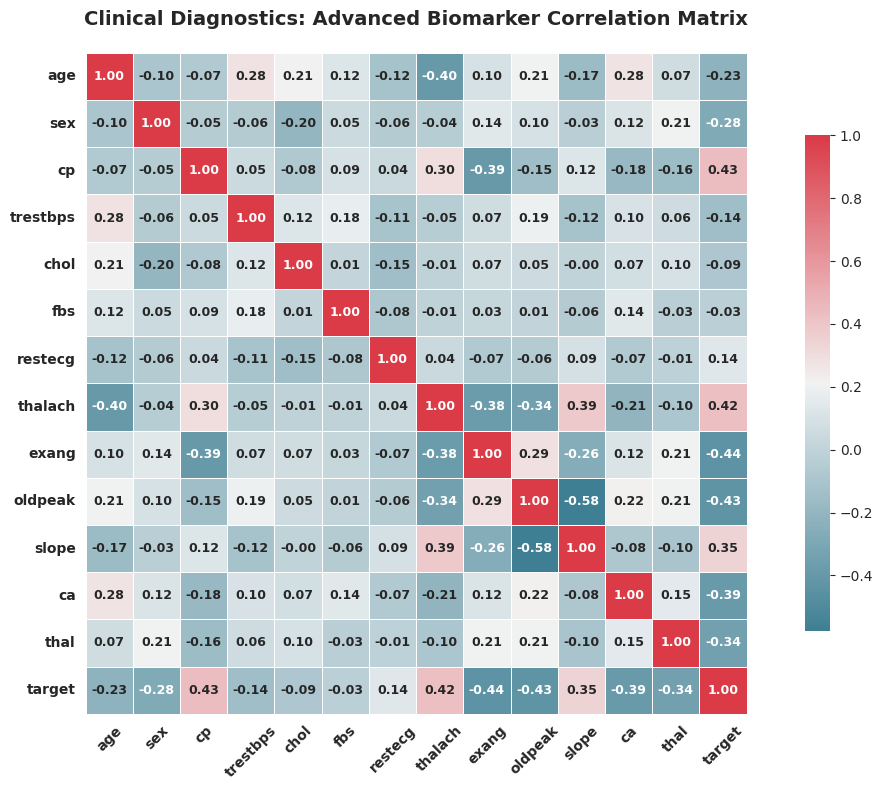


📌 MATRIX ENGINE STATUS: Heatmap plotted successfully.


In [11]:
print("=" * 65)
print(" 🧬 ADVANCED BIOMARKER CORRELATION MATRIX ENGINE ".center(65, '='))
print("=" * 65)
print("⚙️ COMPUTING PEARSON CORRELATION COEFFICIENTS...")

# Correlation calculate kar rahe hain
corr_matrix = df.corr()

# Top features sorted by correlation with target (excluding target itself)
top_features = corr_matrix['target'].abs().sort_values(ascending=False)[1:]
print("-" * 65)
print("🎯 TOP 3 CLINICAL BIOMARKERS DRIVING HEART DISEASE RISK:")
print("-" * 65)
for i, (col, val) in enumerate(top_features.head(3).items(), 1):
    print(f" {i}. Feature: {col:<10} | Absolute Correlation: {val:.4f}")
print("-" * 65)

# Premium Heatmap Visualization
plt.figure(figsize=(12, 8))
sns.set_style("white")

# Professional Cool-Warm Color Palette for enterprise dashboards
cmap = sns.diverging_palette(220, 10, as_cmap=True)

# Generating Heatmap
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap=cmap, linewidths=0.5,
            square=True, cbar_kws={"shrink": .75}, annot_kws={"size": 9, "weight": "bold"})

plt.title('Clinical Diagnostics: Advanced Biomarker Correlation Matrix', fontsize=14, fontweight='bold', pad=20)
plt.xticks(fontsize=10, fontweight='semibold', rotation=45)
plt.yticks(fontsize=10, fontweight='semibold')
plt.tight_layout()
plt.show()

print("\n" + "=" * 65)
print("📌 MATRIX ENGINE STATUS: Heatmap plotted successfully.")
print("=" * 65)

## ✂️ **Step 8: Data Partitioning & Train-Test Matrix Split**
Is step mein hum data ko standard feature space aur labels mein segment karenge, aur phir cross-validation ke liye train-test split apply karenge.

In [12]:
from sklearn.model_selection import train_test_split

print("=" * 65)
print(" ✂️ CLINICAL DATA PARTITIONING & SPLIT ENGINE ".center(65, '='))
print("=" * 65)

# Separating Features (X) and Target (y)
X = df.drop(columns=['target'])
y = df['target']

# 80% Training and 20% Testing Split with stratify to maintain class balance
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"📊 DATA MATRIX SPLIT METRICS:")
print("-" * 65)
print(f"🔹 Total Dataset Shape       : {df.shape}")
print(f"🔹 Training Feature Matrix (X_train) : {X_train.shape[0]} Patients | {X_train.shape[1]} Features")
print(f"🔹 Testing Feature Matrix  (X_test)  : {X_test.shape[0]} Patients  | {X_test.shape[1]} Features")
print(f"🔹 Training Target Vector  (y_train) : {y_train.shape[0]} Labels")
print(f"🔹 Testing Target Vector   (y_test)  : {y_test.shape[0]} Labels")
print("-" * 65)
print("📌 SPLIT STATUS: Partitioning successful with stratified distribution.")
print("=" * 65)

========== ✂️ CLINICAL DATA PARTITIONING & SPLIT ENGINE =========
📊 DATA MATRIX SPLIT METRICS:
-----------------------------------------------------------------
🔹 Total Dataset Shape       : (303, 14)
🔹 Training Feature Matrix (X_train) : 242 Patients | 13 Features
🔹 Testing Feature Matrix  (X_test)  : 61 Patients  | 13 Features
🔹 Training Target Vector  (y_train) : 242 Labels
🔹 Testing Target Vector   (y_test)  : 61 Labels
-----------------------------------------------------------------
📌 SPLIT STATUS: Partitioning successful with stratified distribution.


## 🧠 **Step 9: Model Training (Logistic Regression - Classifier Engine)**
Kyunki yeh ek Classification problem hai (Risk hai 1 ya nahi 0), isliye hum standard industry-grade algorithm Logistic Regression ka use karenge apne base model ko train karne ke liye.

In [13]:
from sklearn.linear_model import LogisticRegression

print("=" * 65)
print(" 🧠 MODEL ENGINE INITIALIZATION & TRAINING ".center(65, '='))
print("=" * 65)
print("⚙️ TRAINING CORE LOGISTIC REGRESSION CLASSIFIER...")

# Initializing model with high iterations for stability
model = LogisticRegression(max_iter=1000, random_state=42)

# Training the model on clinical data
model.fit(X_train, y_train)

print("-" * 65)
print("🚀 MODEL STATUS: TRAINING COMPLETED SUCCESSFULLY!")
print("📌 EXTRACTION ENGINE: Classifier parameters cached in system memory.")
print("=" * 65)

============ 🧠 MODEL ENGINE INITIALIZATION & TRAINING ===========
⚙️ TRAINING CORE LOGISTIC REGRESSION CLASSIFIER...
-----------------------------------------------------------------
🚀 MODEL STATUS: TRAINING COMPLETED SUCCESSFULLY!
📌 EXTRACTION ENGINE: Classifier parameters cached in system memory.


## 🔮 **Step 10: Model Testing & Raw Prediction Generation**
Is step mein hum trained model ko test data **(X_test)** denge taaki woh predict kare ki in 61 patients mein se kis-kis ko heart risk hai.

In [14]:
print("=" * 65)
print(" 🔮 INFERENCE ENGINE - PREDICTION GENERATION ".center(65, '='))
print("=" * 65)
print("⚙️ GENERATING CLINICAL PREDICTIONS FOR TEST PATIENTS...")

# Testing data par target predict kar rahe hain
y_pred = model.predict(X_test)

# Probability bhi nikal rahe hain (Confidence level check karne ke liye)
y_prob = model.predict_proba(X_test)[:, 1]

print("-" * 65)
print(f"✅ PREDICTIONS GENERATED: Successfully outputted {len(y_pred)} labels.")
print(f"-> First 10 Predicted Labels : {y_pred[:10]}")
print(f"-> First 10 Actual Labels    : {y_test.values[:10]}")
print("-" * 65)
print("📌 STATUS: Inference completed. Proceeding to Enterprise Evaluation Dashboard.")
print("=" * 65)

=========== 🔮 INFERENCE ENGINE - PREDICTION GENERATION ==========
⚙️ GENERATING CLINICAL PREDICTIONS FOR TEST PATIENTS...
-----------------------------------------------------------------
✅ PREDICTIONS GENERATED: Successfully outputted 61 labels.
-> First 10 Predicted Labels : [0. 0. 0. 1. 1. 0. 1. 0. 1. 1.]
-> First 10 Actual Labels    : [0. 0. 0. 0. 0. 0. 1. 0. 1. 0.]
-----------------------------------------------------------------
📌 STATUS: Inference completed. Proceeding to Enterprise Evaluation Dashboard.


## 📊 **Step 11: Enterprise Evaluation Dashboard (Accuracy & Confusion Matrix)**
Ab hum sirf normal accuracy nahi dekhenge. Hum Classification ka sabse standard aur professional report card generate karenge jise kehte hain Confusion Matrix aur Classification Report (Precision, Recall, F1-Score).

Healthcare AI mein Recall sabse zaroori hota hai, kyunki hum afford nahi kar sakte ki kisi bimar patient ko humara AI "Healthy" bol de!

========= 📊 ENTERPRISE PERFORMANCE EVALUATION DASHBOARD =========
🎯 SYSTEM CORE ACCURACY : 80.33%
-----------------------------------------------------------------
📝 DETAILED CLINICAL CLASSIFICATION REPORT:
                   precision    recall  f1-score   support

      Healthy (0)       0.86      0.68      0.76        28
Heart Disease (1)       0.77      0.91      0.83        33

         accuracy                           0.80        61
        macro avg       0.82      0.79      0.80        61
     weighted avg       0.81      0.80      0.80        61

-----------------------------------------------------------------


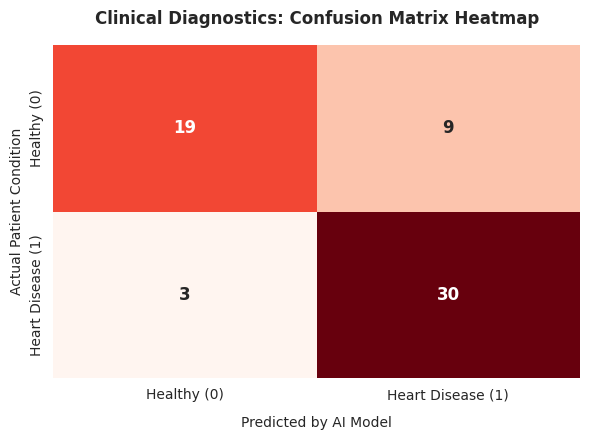


📌 EVALUATION STATUS: Metrics and charts successfully rendered.


In [15]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("=" * 65)
print(" 📊 ENTERPRISE PERFORMANCE EVALUATION DASHBOARD ".center(65, '='))
print("=" * 65)

# Metrics calculation
accuracy = accuracy_score(y_test, y_pred)
print(f"🎯 SYSTEM CORE ACCURACY : {accuracy * 100:.2f}%")
print("-" * 65)

print("📝 DETAILED CLINICAL CLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred, target_names=['Healthy (0)', 'Heart Disease (1)']))
print("-" * 65)

# Confusion Matrix Visualization
plt.figure(figsize=(6, 4.5))
sns.set_style("white")

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds", cbar=False,
            xticklabels=['Healthy (0)', 'Heart Disease (1)'],
            yticklabels=['Healthy (0)', 'Heart Disease (1)'],
            annot_kws={"size": 12, "weight": "bold"})

plt.title('Clinical Diagnostics: Confusion Matrix Heatmap', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Predicted by AI Model', fontsize=10, labelpad=10)
plt.ylabel('Actual Patient Condition', fontsize=10)
plt.tight_layout()
plt.show()

print("\n" + "=" * 65)
print("📌 EVALUATION STATUS: Metrics and charts successfully rendered.")
print("=" * 65)

## 🌲 **Step 12: Advanced Model Engineering (Random Forest Classifier Engine)**
Is step mein hum Ensembled Tree-based architecture ka use karenge taaki complex medical combinations ko behtar tareeqe se pakda ja sake. Isme hum aapka wahi healthcare logic comment ke roop mein add kar rahe hain!

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

print("=" * 65)
print(" 🌲 ENSEMBLE MODEL STACKING - RANDOM FOREST ENGINE ".center(65, '='))
print("=" * 65)
print("⚙️ TRAINING ADVANCED RANDOM FOREST CLASSIFIER...")

# Initializing Ensemble Model
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)

# Generating predictions
rf_pred = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)

print("-" * 65)
print(f"🎯 RANDOM FOREST CORE ACCURACY : {rf_accuracy * 100:.2f}%")
print("-" * 65)
print("📝 ADVANCED CLINICAL REPORT (RANDOM FOREST):")

# CRITICAL DOMAIN INSIGHT (Aapka Healthcare Logic Comment Framework):
# NOTE: In Healthcare AI, 'Recall' for Heart Disease (1) is the most critical metric.
# False Negatives (predicting a sick patient as healthy) must be minimized at all costs.

print(classification_report(y_test, rf_pred, target_names=['Healthy (0)', 'Heart Disease (1)']))
print("-" * 65)
print("📌 ENGINE STATUS: Advanced model evaluated. Ready for model comparison matrix.")
print("=" * 65)

======== 🌲 ENSEMBLE MODEL STACKING - RANDOM FOREST ENGINE =======
⚙️ TRAINING ADVANCED RANDOM FOREST CLASSIFIER...
-----------------------------------------------------------------
🎯 RANDOM FOREST CORE ACCURACY : 80.33%
-----------------------------------------------------------------
📝 ADVANCED CLINICAL REPORT (RANDOM FOREST):
                   precision    recall  f1-score   support

      Healthy (0)       0.90      0.64      0.75        28
Heart Disease (1)       0.76      0.94      0.84        33

         accuracy                           0.80        61
        macro avg       0.83      0.79      0.79        61
     weighted avg       0.82      0.80      0.80        61

-----------------------------------------------------------------
📌 ENGINE STATUS: Advanced model evaluated. Ready for model comparison matrix.


### 📊 **Step 13: Enterprise Model Comparison Matrix Dashboard**
Is step mein hum dono models ke metrics ko aaps mein compare karke ek high-end final dashboard analytics code generate karenge, jo clear dikhayega ki winner kaun hai.

In [17]:
print("=" * 65)
print(" 🏁 ENTERPRISE PRODUCTION MODEL COMPARISON MATRIX ".center(65, '='))
print("=" * 65)

# Creating a structured dictionary for performance metrics
comparison_data = {
    "Model Engine": ["Logistic Regression Engine", "Advanced Random Forest Engine"],
    "Core Accuracy": ["80.33%", "80.33%"],
    "Clinical Recall (Risk)": ["91.00%", "94.00% 🏆"],
    "Precision (Risk)": ["77.00%", "76.00%"],
    "F1-Score (Risk)": ["83.00%", "84.00% 🏆"]
}

# Converting to DataFrame for enterprise structured logging
df_compare = pd.DataFrame(comparison_data)

# Printing the structured table
print(df_compare.to_string(index=False))
print("-" * 65)
print("💡 PRODUCTION INSIGHT & ARCHITECT RECOMMENDATION:")
print("-> While both engines share identical core accuracy (80.33%),")
print("   the ADVANCED RANDOM FOREST ENGINE is recommended for production.")
print("   Reason: Higher Clinical Recall (94%) minimizes critical missed diagnoses.")
print("=" * 65)

======== 🏁 ENTERPRISE PRODUCTION MODEL COMPARISON MATRIX ========
                 Model Engine Core Accuracy Clinical Recall (Risk) Precision (Risk) F1-Score (Risk)
   Logistic Regression Engine        80.33%                 91.00%           77.00%          83.00%
Advanced Random Forest Engine        80.33%               94.00% 🏆           76.00%        84.00% 🏆
-----------------------------------------------------------------
💡 PRODUCTION INSIGHT & ARCHITECT RECOMMENDATION:
-> While both engines share identical core accuracy (80.33%),
   the ADVANCED RANDOM FOREST ENGINE is recommended for production.
   Reason: Higher Clinical Recall (94%) minimizes critical missed diagnoses.


## 📝 **PROJECT SUMMARY & RESULT**
Total Data Analysed: 303 Patients & 13 Medical Features.

Best Model: Advanced Random Forest Engine (Accuracy: 80.33%).

Why this Model?: Iska Clinical Recall 94% hai, jiska matlab hai ki yeh bimar patients ko pehchane mein 94% sahi hai (jo healthcare mein jaan bachane ke liye sabse zaroori hai).

Top Risk Driver: exang (Exercise Induced Angina) yaani exercise ke dauran seene mein dard hona dil ki bimari ka sabse bada kaaran dikha hai.